<a href="https://colab.research.google.com/github/MahuL88/Latihan/blob/main/Latihan_FeatureEngineering_Overfit%26Underfit_Dicoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering

## Impor Library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

## Membuat Random Dataset

In [ ]:
# membuat 1k data dengan 15 fitur dan membagi rasio 90% utk kelas pertama
X, y = make_classification(n_samples=1000, n_features=15, n_informative=10, n_redundant=2,n_clusters_per_class=1, weights=[0.9], flip_y=0, random_state=42)

In [ ]:
# Mengubah nilai acak yg tersimpan dgn tipe data array menjadi DataFrame
df = pd.DataFrame(X, columns=[f'Fitur_{i}' for i in range(1, 16)])
df['Target'] = y

# simulasi fitur kategorikal(membuat 2 fitur menjadi kategorikal)
df['Fitur_12'] = np.random.choice(['A', 'B', 'C'], size=1000)
df['Fitur_13'] = np.random.choice(['X', 'Y', 'Z'], size=1000)

df

,Fitur_1,Fitur_2,Fitur_3,Fitur_4,Fitur_5,Fitur_6,Fitur_7,Fitur_8,Fitur_9,Fitur_10,Fitur_11,Fitur_12,Fitur_13,Fitur_14,Fitur_15,Target
0,0.093303,-3.472520,-1.314199,3.525743,0.642138,2.247328,3.067502,1.146301,-2.173112,2.765828,-1.821258,B,X,1.005559,-0.276558,0
1,-0.189574,-1.770842,-1.578851,-1.372201,-2.025230,0.518655,-0.764750,-3.958705,-0.598147,1.018789,4.194233,C,X,-0.243630,0.285979,0
2,0.916269,-2.051770,3.631998,0.824844,1.674093,-0.436273,-0.460407,0.031633,-1.140149,2.069694,1.935251,B,X,2.486020,-2.867291,0
3,-0.914665,-1.608657,-0.735184,-1.742743,-1.753532,0.383412,-1.057937,-2.897416,-0.830328,1.572469,5.334621,B,Y,-0.788215,1.255376,0
4,-0.756784,-2.362885,-3.909120,-0.474571,-4.029843,0.947114,0.581146,-3.435229,-2.142380,2.332385,3.816539,C,Z,0.712335,2.810524,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.927482,-0.017325,4.884411,0.542628,3.033376,-1.904407,0.953035,1.278882,-1.293396,1.772169,-1.191263,B,Y,-0.387151,-2.629004,0
996,0.347761,-1.690916,5.949207,-2.289729,2.238469,-0.067922,-0.069702,-1.436622,-2.153011,-0.867583,3.962758,B,Y,0.886822,-1.248408,0
997,1.201967,-1.263417,-1.331925,-2.468434,1.777577,2.270456,-0.431749,-1.846263,1.753033,1.858452,4.264568,B,Y,0.067260,0.931995,1
998,-2.127846,-0.975838,0.279144,0.151578,-0.443749,0.650616,-1.410265,-1.017319,-0.643070,2.142898,3.399255,B,Y,-0.128774,0.800834,0


In [ ]:
# Memisahkan fitur dan target
X = df.drop('Target', axis=1)
y = df['Target']

In [ ]:
print("Distribusi kelas sebelum SMOTE:", Counter(y))

Distribusi kelas sebelum SMOTE: Counter({0: 901, 1: 99})


## Feature Selection

In [ ]:
# Seleksi Fitur menggunakan Metode Embedded
# Menggunakan Random Forest untuk mendapatkan fitur penting
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# latih model dengan 100 pohon dan fitur yang numerik
X_integer = X.drop(['Fitur_12', 'Fitur_13'], axis=1)
rf_model.fit(X_integer, y)

# Mendapatkan fitur penting
importances = rf_model.feature_importances_
# Menghasilkan index dengan urutan berdasarkan nilai elemen yg diurutkan dari besar ke kecil
indices = np.argsort(importances)[::-1]

# Menentukan ambang batas untuk fitur penting
threshold = 0.05  # Misalnya, ambang batas 5%
important_features_indices = [i for i in range(len(importances)) if importances[i] >= threshold]

# Menampilkan fitur penting beserta nilainya
print("Fitur yang dipilih dengan Embedded Methods (di atas ambang batas):")
for i in important_features_indices:
    # Jika X asli berbentuk DataFrame, maka kita ambil nama kolom
    print(f"{X_integer.columns[i]}: {importances[i]}")

# Mendapatkan nama kolom penting berdasarkan importance
important_features = X_integer.columns[important_features_indices]

# Memindahkan fitur penting dan isinya ke variabel baru
X_important = X_integer[important_features]

# X_important sekarang berisi hanya fitur penting
print("\nDimensi data pelatihan dengan fitur penting:", X_important.shape)

Fitur yang dipilih dengan Embedded Methods (di atas ambang batas):
Fitur_2: 0.11860019897866206
Fitur_3: 0.06878603593465271
Fitur_5: 0.07731131335837178
Fitur_8: 0.050482655781999855
Fitur_9: 0.2625049418105367
Fitur_10: 0.08958259568334655
Fitur_11: 0.06365230544114515
Fitur_15: 0.12578161860669113

Dimensi data pelatihan dengan fitur penting: (1000, 8)


In [ ]:
# gabungkan data kategorikal
X_Selected = pd.concat([X_important, X['Fitur_12']], axis=1)
X_Selected = pd.concat([X_Selected, X['Fitur_13']], axis=1)
X_Selected

,Fitur_2,Fitur_3,Fitur_5,Fitur_8,Fitur_9,Fitur_10,Fitur_11,Fitur_15,Fitur_12,Fitur_13
0,-3.472520,-1.314199,0.642138,1.146301,-2.173112,2.765828,-1.821258,-0.276558,B,X
1,-1.770842,-1.578851,-2.025230,-3.958705,-0.598147,1.018789,4.194233,0.285979,C,X
2,-2.051770,3.631998,1.674093,0.031633,-1.140149,2.069694,1.935251,-2.867291,B,X
3,-1.608657,-0.735184,-1.753532,-2.897416,-0.830328,1.572469,5.334621,1.255376,B,Y
4,-2.362885,-3.909120,-4.029843,-3.435229,-2.142380,2.332385,3.816539,2.810524,C,Z
...,...,...,...,...,...,...,...,...,...,...
995,-0.017325,4.884411,3.033376,1.278882,-1.293396,1.772169,-1.191263,-2.629004,B,Y
996,-1.690916,5.949207,2.238469,-1.436622,-2.153011,-0.867583,3.962758,-1.248408,B,Y
997,-1.263417,-1.331925,1.777577,-1.846263,1.753033,1.858452,4.264568,0.931995,B,Y
998,-0.975838,0.279144,-0.443749,-1.017319,-0.643070,2.142898,3.399255,0.800834,B,Y


## label Encoding

In [ ]:
label_encoder = LabelEncoder()
# Melakukan Encoding untuk fitur 12
X_Selected['Fitur_12'] = label_encoder.fit_transform(X_Selected['Fitur_12'])
# print(label_encoder.inverse_transform(X_Selected[['Fitur_12']]))
# Melakukan Encoding untuk fitur 13
X_Selected['Fitur_13'] = label_encoder.fit_transform(X_Selected['Fitur_13'])
# print(label_encoder.inverse_transform(X_Selected[['Fitur_13']]))

print(X_Selected)


      Fitur_2   Fitur_3   Fitur_5   Fitur_8   Fitur_9  Fitur_10  Fitur_11  \
0   -3.472520 -1.314199  0.642138  1.146301 -2.173112  2.765828 -1.821258   
1   -1.770842 -1.578851 -2.025230 -3.958705 -0.598147  1.018789  4.194233   
2   -2.051770  3.631998  1.674093  0.031633 -1.140149  2.069694  1.935251   
3   -1.608657 -0.735184 -1.753532 -2.897416 -0.830328  1.572469  5.334621   
4   -2.362885 -3.909120 -4.029843 -3.435229 -2.142380  2.332385  3.816539   
..        ...       ...       ...       ...       ...       ...       ...   
995 -0.017325  4.884411  3.033376  1.278882 -1.293396  1.772169 -1.191263   
996 -1.690916  5.949207  2.238469 -1.436622 -2.153011 -0.867583  3.962758   
997 -1.263417 -1.331925  1.777577 -1.846263  1.753033  1.858452  4.264568   
998 -0.975838  0.279144 -0.443749 -1.017319 -0.643070  2.142898  3.399255   
999  1.387667 -5.554578 -2.834755 -1.932864  2.625895  0.246120  0.786726   

     Fitur_15  Fitur_12  Fitur_13  
0   -0.276558         1         0  
1  

## Handling Outliers

In [ ]:
# Memilih kolom numerik
numeric_columns = X_Selected.select_dtypes(include=['float64', 'int64']).columns
numeric_columns = numeric_columns.drop(['Fitur_12', 'Fitur_13'])

# Membuat salinan data untuk menjaga data asli tetap utuh
X_cleaned = X_important.copy()

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


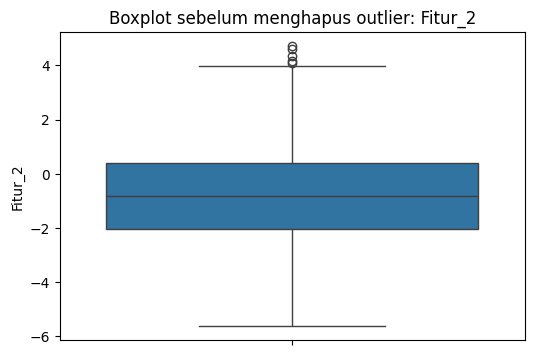

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


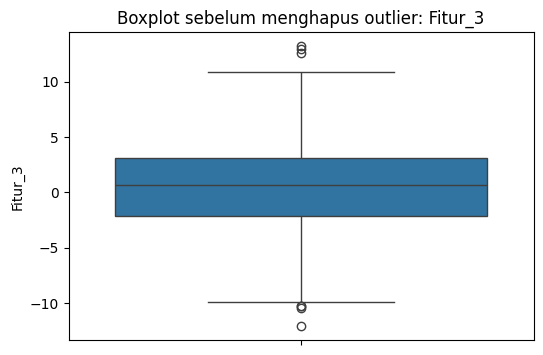

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


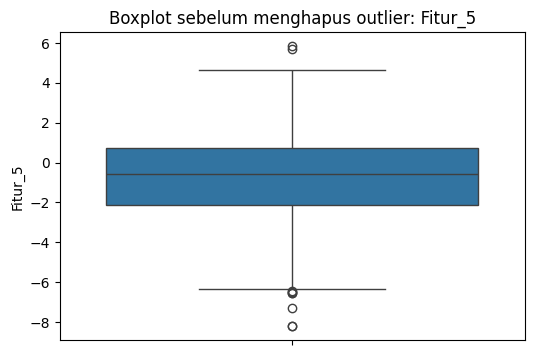

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


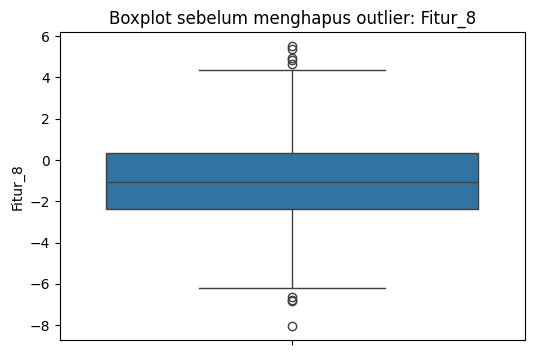

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


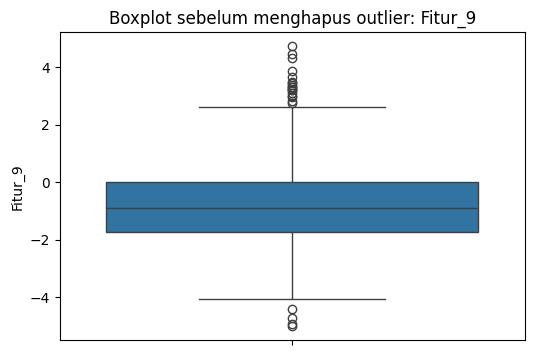

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


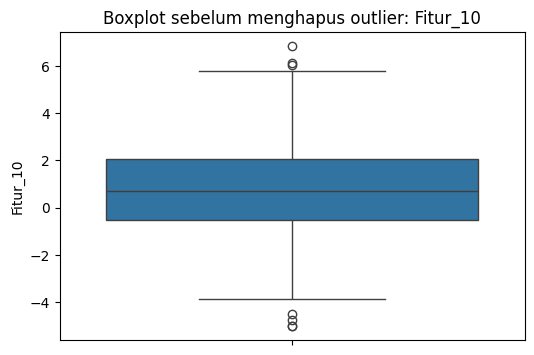

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


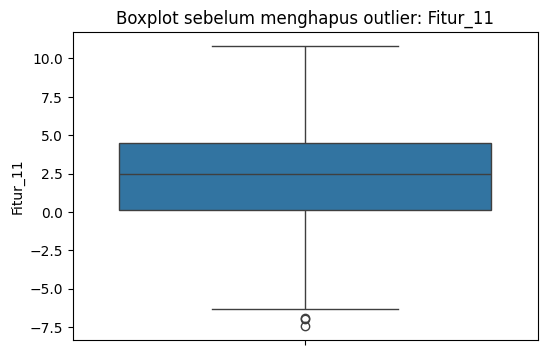

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


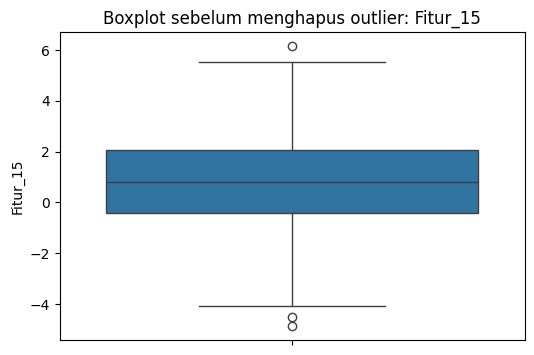

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=X_important[col], orient='h')
    plt.title(f'Boxplot sebelum menghapus outlier: {col}')
    plt.show()

In [ ]:
for col in numeric_columns:
    # Hitung IQR dari X_important
    Q1 = X_important[col].quantile(0.25)
    Q3 = X_important[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identifikasi outlier berdasarkan X_important
    outliers = X_important[(X_important[col] < lower_bound) | (X_important[col] > upper_bound)]

    # Drop dari semua dataset agar sinkron
    X_important = X_important.drop(outliers.index)
    X_cleaned  = X_cleaned.drop(outliers.index)
    y          = y.drop(outliers.index)
# Reset index
X_important = X_important.reset_index(drop=True)
X_cleaned   = X_cleaned.reset_index(drop=True)
y           = y.reset_index(drop=True)

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


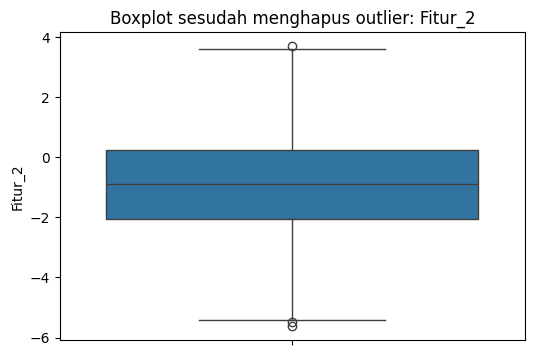

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


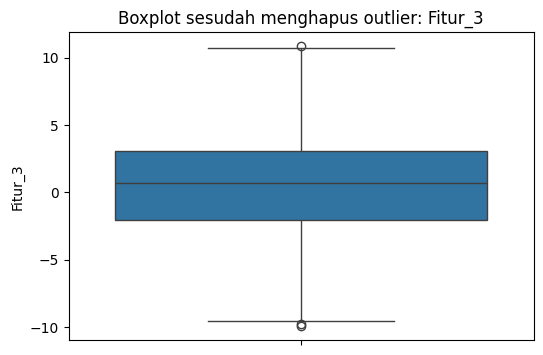

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


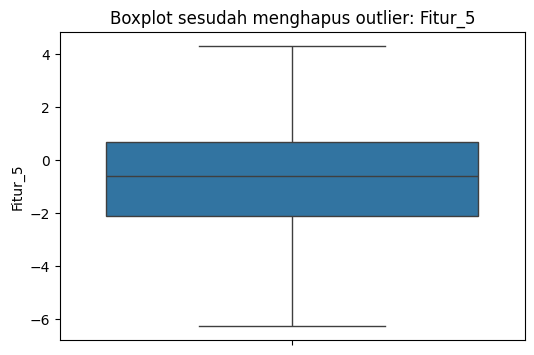

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


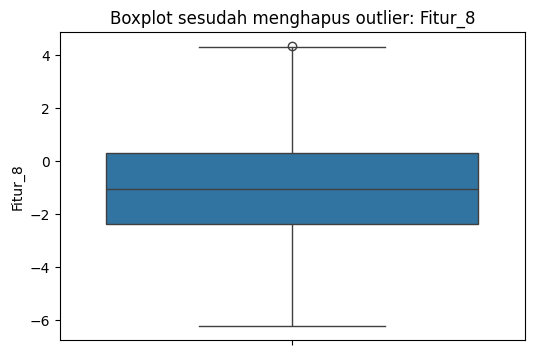

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


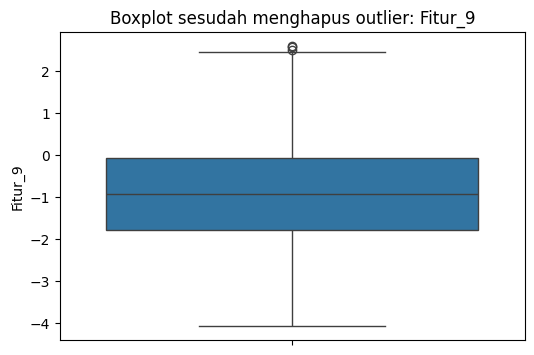

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


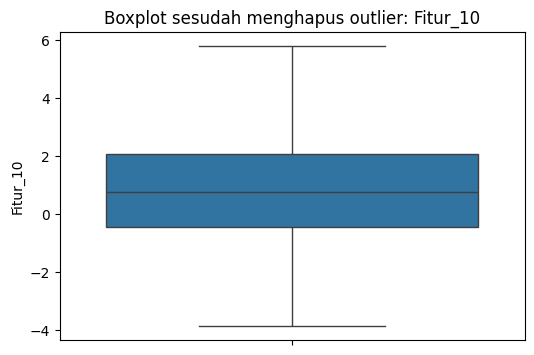

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


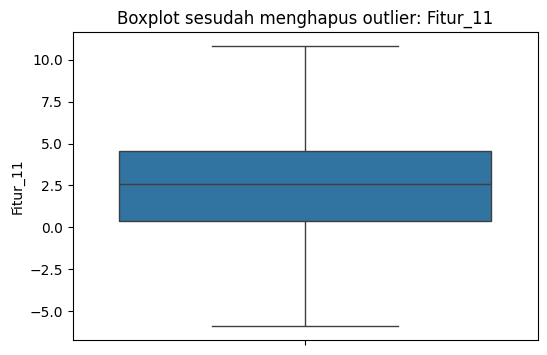

/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1601: UserWarning: Horizontal orientation ignored with only `y` specified.
  warnings.warn(single_var_warning.format("Horizontal", "y"))


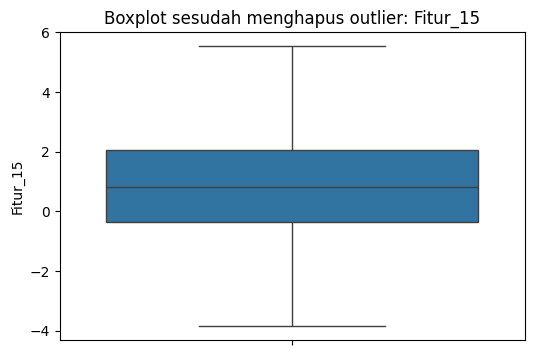

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=X_important[col], orient='h')
    plt.title(f'Boxplot sesudah menghapus outlier: {col}')
    plt.show()

In [ ]:
 X_cleaned

,Fitur_2,Fitur_3,Fitur_5,Fitur_8,Fitur_9,Fitur_10,Fitur_11,Fitur_15
0,-3.472520,-1.314199,0.642138,1.146301,-2.173112,2.765828,-1.821258,-0.276558
1,-1.770842,-1.578851,-2.025230,-3.958705,-0.598147,1.018789,4.194233,0.285979
2,-2.051770,3.631998,1.674093,0.031633,-1.140149,2.069694,1.935251,-2.867291
3,-1.608657,-0.735184,-1.753532,-2.897416,-0.830328,1.572469,5.334621,1.255376
4,-2.362885,-3.909120,-4.029843,-3.435229,-2.142380,2.332385,3.816539,2.810524
...,...,...,...,...,...,...,...,...
939,-2.041914,-0.803401,-0.697435,2.116836,-1.075422,2.308076,-0.972784,0.056426
940,-0.017325,4.884411,3.033376,1.278882,-1.293396,1.772169,-1.191263,-2.629004
941,-1.690916,5.949207,2.238469,-1.436622,-2.153011,-0.867583,3.962758,-1.248408
942,-1.263417,-1.331925,1.777577,-1.846263,1.753033,1.858452,4.264568,0.931995


In [ ]:
X_cleaned.shape

(944, 8)

In [ ]:
Counter(y)

Counter({0: 873, 1: 71})

## Handling Imbalance Dataset

In [ ]:
# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Melakukan oversampling pada dataset
X_resampled, y_resampled = smote.fit_resample(X_cleaned, y)

# Menampilkan distribusi kelas setelah SMOTE
print("Distribusi kelas setelah SMOTE:", Counter(y_resampled))

# Mengubah hasil menjadi DataFrame untuk visualisasi atau analisis lebih lanjut
X_resampled = pd.DataFrame(X_resampled)
y_resampled = pd.Series(y_resampled, name='Target')

Distribusi kelas setelah SMOTE: Counter({0: 873, 1: 873})


## Scaling(Normalization/Standarization)

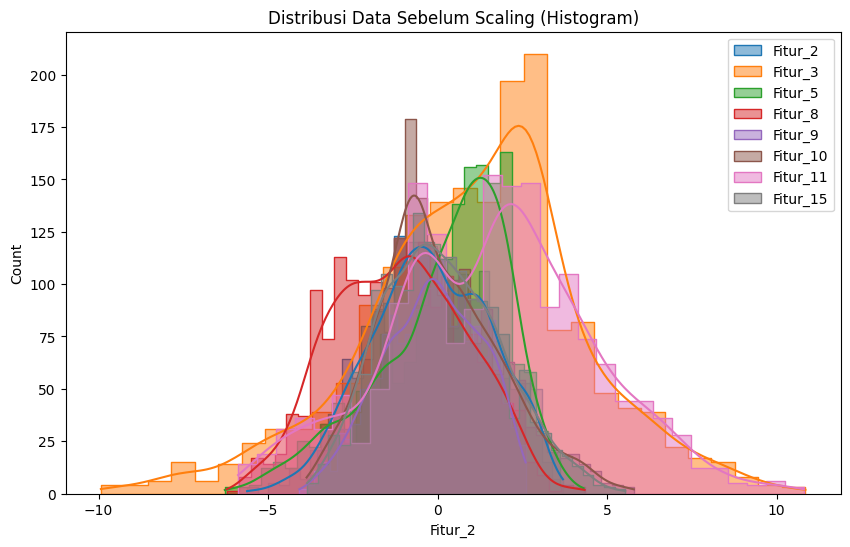

In [ ]:
# Visualisasi distribusi data sebelum scaling menggunakan histogram
plt.figure(figsize=(10, 6))
for col in X_resampled.columns:
    sns.histplot(X_resampled[col], kde=True, label=col, bins=30, element='step')
plt.title('Distribusi Data Sebelum Scaling (Histogram)')
plt.legend()
plt.show()

In [ ]:
# Standarisasi fitur numerik menggunakan StandardScaler
scaler = StandardScaler()

# Melakukan scaling pada fitur penting
X_resampled[important_features] = scaler.fit_transform(X_resampled[important_features])

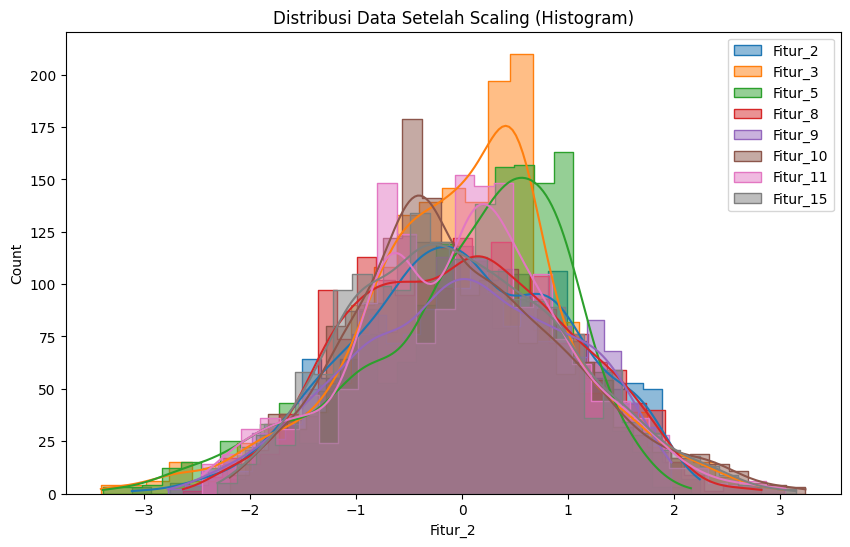

In [ ]:
# Visualisasi distribusi data setelah scaling menggunakan histogram
plt.figure(figsize=(10, 6))
for col in X_resampled.columns:
    sns.histplot(X_resampled[col], kde=True, label=col, bins=30, element='step')
plt.title('Distribusi Data Setelah Scaling (Histogram)')
plt.legend()
plt.show()

In [ ]:
X_resampled.describe(include='all')
# Terlihat bahwa mean 0 atau mendekati 0 serta std 1 atau mendekati 1

,Fitur_2,Fitur_3,Fitur_5,Fitur_8,Fitur_9,Fitur_10,Fitur_11,Fitur_15
count,1.746000e+03,1.746000e+03,1746.000000,1.746000e+03,1746.000000,1746.000000,1.746000e+03,1746.000000
mean,6.511274e-17,-1.627818e-17,0.000000,-8.139092e-18,0.000000,0.000000,-6.511274e-17,0.000000
std,1.000286e+00,1.000286e+00,1.000286,1.000286e+00,1.000286,1.000286,1.000286e+00,1.000286
min,-3.112360e+00,-3.404459e+00,-3.386517,-2.630723e+00,-2.774277,-2.190744,-2.450540e+00,-2.306398
25%,-6.959136e-01,-6.003198e-01,-0.580845,-7.678686e-01,-0.737271,-0.676480,-6.684905e-01,-0.768312
50%,-8.431187e-03,5.484814e-02,0.215867,1.498202e-02,0.035358,-0.170095,7.818691e-02,-0.064777
75%,7.677592e-01,5.818902e-01,0.742510,7.380397e-01,0.781062,0.672320,6.625394e-01,0.706985
max,2.241613e+00,3.031189e+00,2.157473,2.823034e+00,1.972949,3.237494,3.048803e+00,3.149071


# Overfitting dan Underfitting

## Impor Library

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

## Load Data

In [ ]:
# Load dataset California Housing
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Membagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
# Inisialisasi model Decision Tree Regressor
model = DecisionTreeRegressor(max_depth=50, random_state=42)

# Melatih model dengan data latih
model.fit(X_train, y_train)

# Membuat prediksi untuk data latih dan data uji
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Deteksi Overfit


### Evaluasi Performa

In [ ]:
# Menghitung Mean Squared Error (MSE) untuk data latih dan data uji
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Menampilkan hasil MSE
# Terlihat nilai training dan test sangat berbeda(overfit)
print(f'Training MSE: {train_mse}')
print(f'Test MSE: {test_mse}')

Training MSE: 9.904697258622977e-32
Test MSE: 0.5265256772490148


### Learning Curve

Train sizes ukuran data yg dipakai setiap langkah(maks 5), train scores itu 5 nilai MSE utk setiap ukuran, test scores itu 5 nilai MSE validasi(sisa data ukuran) utk setiap ukuran. Sklearn mengembalikan negatif MSE, sehingga digunakan tanda (-) agar positif.

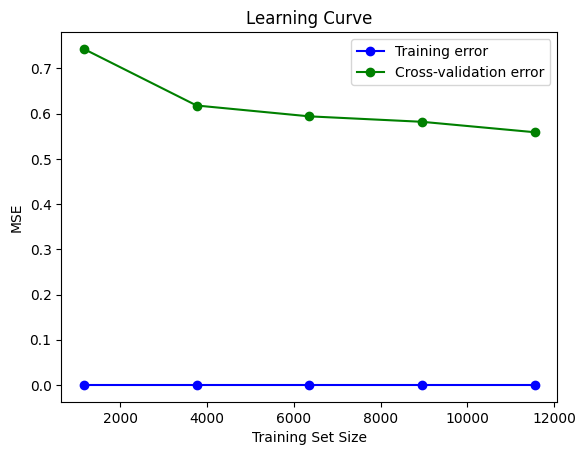

In [ ]:
# scoring='neg_mean_squared_error' digunakan untuk mengevaluasi model berdasarkan MSE
# n_jobs=-1 memungkinkan perhitungan paralel untuk mempercepat proses pelatihan.
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Menghitung rata-rata setiap ukuran per baris(axis=1)
train_mean = -np.mean(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)

# Plot learning curve
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation error")
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.legend()
plt.show()

Terlihat bahwa learning curve menunjukkan jarak yang sangat jauh antara training error dan cross-validation error(overfit)

## Mengatasi Overfitting

### CV

cross_val_score mengambil MSE dari data validasi/test, nilai CV dan test dibandingkan untuk cek stabilitas. jika CV MSE mendekati test MSE, model lebih stabil dalam generalisasi walaupun overfit di data training. artinya, CV memberi gambaran seberapa baik/konsisten model akan bekerja di data baru(yg tidak pernah di latih)

In [ ]:
# Menggunakan cross-validation dengan 5 fold
cross_val_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Menampilkan hasil cross-validation
print(f'Cross-Validation MSE: {-cross_val_scores.mean()}')

Cross-Validation MSE: 0.5562691658603186


Meskipun hasil Cross-Validation MSE sudah lebih stabil, training MSE sebelumnya sangat kecil, sehingga belum optimal.

### Regularization

In [ ]:
# Membuat model Decision Tree dengan kedalaman pohon yang lebih kecil(5)
model_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
model_reg.fit(X_train, y_train)

# Evaluasi pada data latih dan uji
y_train_pred_reg = model_reg.predict(X_train)
y_test_pred_reg = model_reg.predict(X_test)

# Hitung MSE
train_mse_reg = mean_squared_error(y_train, y_train_pred_reg)
test_mse_reg = mean_squared_error(y_test, y_test_pred_reg)

print(f'Training MSE (After Regularization): {train_mse_reg}')
print(f'Test MSE (After Regularization): {test_mse_reg}')

Training MSE (After Regularization): 0.4928096322147045
Test MSE (After Regularization): 0.5210801561811793


Sekarang, perbedaan antara Training MSE dan Test MSE menjadi lebih kecil yang menandakan seimbang. yang artinya model lebih mampu memprediksi data baru dengan lebih akurat(tapi nilai MSE masih cukup tinggi).

### Pruning

Melakukan pruning Manual pada Kedalaman Pohon. Teknik yang digunakan adalah Cost Complexity Pruning dengan parameter ccp_alpha. Hal ini memungkinkan  cabang-cabang pohon yang kurang penting dipangkas. Semakin besar nilai ccp_alphas, semakin banyak pemangkasan dilakukan.

In [ ]:
# Menggunakan ccp_alpha untuk pruning (Cost Complexity Pruning)
# Menghitung nilai alpha
path = model.cost_complexity_pruning_path(X_train, y_train)
# daftar nilai alpha (≥0) yang bisa digunakan untuk pruning(pemotongan).
ccp_alphas = path.ccp_alphas

# Melatih model dengan pruning dengan memilih nilai alpha kedua terbesar
model_pruned = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alphas[-2])
model_pruned.fit(X_train, y_train)

# Membuat prediksi
y_train_pred_pruned = model_pruned.predict(X_train)
y_test_pred_pruned = model_pruned.predict(X_test)

# Menghitung MSE
train_mse_pruned = mean_squared_error(y_train, y_train_pred_pruned)
test_mse_pruned = mean_squared_error(y_test, y_test_pred_pruned)

print(f'Pruned Model Training MSE: {train_mse_pruned}')
print(f'Pruned Model Test MSE: {test_mse_pruned}')

Pruned Model Training MSE: 0.9189620181001872
Pruned Model Test MSE: 0.9194598144703808


sama seperti Reg, perbedaan antara MSE pada data latih dan data uji sudah sangat kecil yang menandakan seimbang. Meskipun nilai MSE pada data latih meningkat dibandingkan model sebelumnya, kemampuan model untuk melakukan generalisasi dalam data baru menjadi lebih baik dan lebih stabil. (tapi nilai MSE lebih tinggi).

### Data Augmentation

augmentasi dilakukan dengan menambahkan sedikit noise atau gangguan pada data latih. Noise ini merupakan gangguan acak yang tidak signifikan, tetapi cukup untuk memberikan variasi pada data latih.

In [ ]:
# Menambahkan sedikit noise ke data sebagai augmentasi dgn mean 0, std 0.1 sebanyak X_train
X_train_aug = X_train + np.random.normal(0, 0.1, X_train.shape)

# Melatih ulang model dengan augmented data
model_aug = DecisionTreeRegressor(max_depth=10, random_state=42)
model_aug.fit(X_train_aug, y_train)

# Membuat prediksi
y_train_pred_aug = model_aug.predict(X_train_aug)
y_test_pred_aug = model_aug.predict(X_test)

# Menghitung MSE
train_mse_aug = mean_squared_error(y_train, y_train_pred_aug)
test_mse_aug = mean_squared_error(y_test, y_test_pred_aug)

print(f'Augmented Data Training MSE: {train_mse_aug}')
print(f'Augmented Data Test MSE: {test_mse_aug}')

Augmented Data Training MSE: 0.3253315247939224
Augmented Data Test MSE: 0.505424350345044


terlihat, data augmentation membantu mengurangi overfitting dengan membuat model lebih adaptif terhadap variasi dalam data latih meskipun hasil pada data uji tetap stabil. (tapi nilai MSE lebih tinggi).

### Dropout

Menggunakan RF karena DT tidak dapat menerapkan dropout secara langsung

In [ ]:
# Inisialisasi Random Forests dengan n_estimators (jumlah pohon)
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Melatih model
model_rf.fit(X_train, y_train)

# Membuat prediksi
y_train_pred_rf = model_rf.predict(X_train)
y_test_pred_rf = model_rf.predict(X_test)

# Menghitung MSE
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)

print(f'Random Forest Training MSE: {train_mse_rf}')
print(f'Random Forest Test MSE: {test_mse_rf}')

Random Forest Training MSE: 0.1694494883912745
Random Forest Test MSE: 0.2944600120852388


Meskipun MSE dalam data latih sedikit meningkat dibandingkan dengan model awal, MSE pada data uji menunjukkan penurunan yang signifikan. Ini menandakan bahwa model Random Forest lebih baik dalam mengatasi overfitting dan memberikan hasil yang lebih stabil saat diterapkan pada data baru. (nilai MSE lebih baik dari metode sebelumnya).

## Impor Library

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

## Load Data

In [ ]:
# Load dataset (Breast Cancer Dataset)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Membagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Membuat model Underfitting (Decision Tree dengan max_depth rendah)
model_underfit = DecisionTreeClassifier(max_depth=1, random_state=42)
model_underfit.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1, random_state=42)

In [ ]:
# Prediksi
y_train_pred_underfit = model_underfit.predict(X_train)
y_test_pred_underfit = model_underfit.predict(X_test)

## Deteksi Underfit

### Evaluasi performa

In [ ]:
train_acc_underfit = accuracy_score(y_train, y_train_pred_underfit)
test_acc_underfit = accuracy_score(y_test, y_test_pred_underfit)

print(f"Underfit Model Training Accuracy: {train_acc_underfit}")
print(f"Underfit Model Test Accuracy: {test_acc_underfit}")

Underfit Model Training Accuracy: 0.9246231155778895
Underfit Model Test Accuracy: 0.8947368421052632


Meskipun tidak terlihat underfitting, model ini masih belum mencapai akurasi test yang optimal. Perbedaan ini menunjukkan bahwa model tidak terlalu menyesuaikan diri dengan data latih, tetapi juga tidak menangkap pola yang cukup baik untuk memprediksi data uji dengan akurasi lebih tinggi.

### Learning Curve

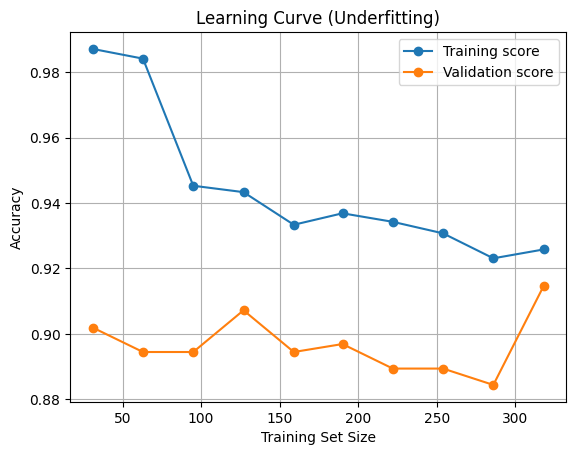

In [ ]:
# scoring='accuracy' digunakan untuk mengevaluasi model berdasarkan akurasi ukuran train dari 0.1 sampai 1.0 sebanyak 10 nilai.
train_sizes, train_scores, test_scores = learning_curve(model_underfit, X_train, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot Learning Curve
plt.figure()
plt.plot(train_sizes, train_scores_mean, 'o-', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Validation score')
plt.ylabel('Accuracy')
plt.xlabel('Training Set Size')
plt.title('Learning Curve (Underfitting)')
plt.legend()
plt.grid(True)
plt.show()

baik skor pelatihan maupun skor validasi tidak meningkat secara signifikan dengan bertambahnya ukuran data. akan tetapi, Semakin banyak data, Pola data baru mulai tertangkap ketika train size semakin besar. ini mengindikasikan bahwa model mungkin tidak cukup kompleks(butuh lebih banyak data) untuk menangkap pola dalam data agar menjadi stabil dan akurasinya meningkat.

## Mengatasi Underfitting

### Model yang lebih Kompleks

In [ ]:
# Membandingkan dengan model yang lebih kompleks (ex; max_depth=5)
model_complex = DecisionTreeClassifier(max_depth=5, random_state=42)
model_complex.fit(X_train, y_train)

y_train_pred_complex = model_complex.predict(X_train)
y_test_pred_complex = model_complex.predict(X_test)

train_acc_complex = accuracy_score(y_train, y_train_pred_complex)
test_acc_complex = accuracy_score(y_test, y_test_pred_complex)

print(f"Complex Model Training Accuracy: {train_acc_complex}")
print(f"Complex Model Test Accuracy: {test_acc_complex}")

Complex Model Training Accuracy: 0.9949748743718593
Complex Model Test Accuracy: 0.9532163742690059


Terlihat Bahwa setelah model ditambahkan kedalamannya(semakin kompleks), nilai akurasi dari keduanya meningkat. hal ini menandakan bahwa model underfitting dan perlu meningkatkan kompleksitas

In [ ]:
# Menggunakan model yang lebih kompleks dengan max_depth lebih besar
complex_model = DecisionTreeClassifier(max_depth=10, random_state=42)
complex_model.fit(X_train, y_train)

# Prediksi pada data latih dan uji
y_train_pred_complex = complex_model.predict(X_train)
y_test_pred_complex = complex_model.predict(X_test)

# Evaluasi performa
train_acc_complex = accuracy_score(y_train, y_train_pred_complex)
test_acc_complex = accuracy_score(y_test, y_test_pred_complex)

print(f"Training Accuracy (Complex Model): {train_acc_complex}")
print(f"Test Accuracy (Complex Model): {test_acc_complex}")

Training Accuracy (Complex Model): 1.0
Test Accuracy (Complex Model): 0.9415204678362573


Terlihat lagi bahwa ketika kedalamannya lebih kompleks, nilai akurasi training mengalami peningkatan signifikan dan sangat akurat(bernilai 1), sedangkan testnya berkurang menjadi 0.94.  Ini menunjukkan bahwa model sekarang lebih mampu menangkap pola data dan mengatasi underfit, namun terindikasi overfit, karena training bisa memprediksi semua target di training, sedangkan di test dia tidak mampu.

### Feature Selection dengan PCA

In [ ]:
# Normalisasi data sebelum menggunakan PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA untuk mengurangi dimensi atau menghasilkan fitur baru
pca = PCA(n_components=5)  # Mendefinisikan 5 fitur baru yg akan dibuat dari data asli
X_pca = pca.fit_transform(X_scaled) # Masukkan data, sesuaikan, dan buat 5 fitur tersebut

# Membagi data menjadi data latih dan data uji
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Model dengan fitur hasil PCA
complex_model_pca = DecisionTreeClassifier(max_depth=10, random_state=42)
complex_model_pca.fit(X_train_pca, y_train_pca)

# Prediksi pada data latih dan uji
y_train_pred_pca = complex_model_pca.predict(X_train_pca)
y_test_pred_pca = complex_model_pca.predict(X_test_pca)

# Evaluasi performa
train_acc_pca = accuracy_score(y_train_pca, y_train_pred_pca)
test_acc_pca = accuracy_score(y_test_pca, y_test_pred_pca)

print(f"Training Accuracy (PCA): {train_acc_pca}")
print(f"Test Accuracy (PCA): {test_acc_pca}")

Training Accuracy (PCA): 1.0
Test Accuracy (PCA): 0.9415204678362573


Sama seperti complex model dengan max depth 10, nilai training dan testnya memiliki nilai yang sama. artinya mteode ini juga cocok untuk mengatasi underfit namun terindikasi overfit pada kasus ini.

 ### Hyperparameter Tuning Menggunakan GridSearchCV

In [ ]:
# Grid Search untuk hyperparameter tuning
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid, cv=5, scoring='accuracy')

# Melakukan pencarian hyperparameter(model) terbaik
grid_search.fit(X_train, y_train)

# Parameter dari Hyperparameter terbaik
best_params = grid_search.best_params_
# model terbaik yang sudah di latih
best_model = grid_search.best_estimator_

# Prediksi dengan model terbaik
y_train_pred_best = best_model.predict(X_train)
y_test_pred_best = best_model.predict(X_test)

# Evaluasi performa
train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print(f"Training Accuracy (Best Model): {train_acc_best}")
print(f"Test Accuracy (Best Model): {test_acc_best}")
print(f"Best Params: {best_params}")

Training Accuracy (Best Model): 0.9949748743718593
Test Accuracy (Best Model): 0.9532163742690059
Best Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


Terlihat bahwa akurasinya mirip dengan metode pertama yang menggunakan max depth = 5, hal ini dikarenakan best paramsnya juga bernilai 5

### Perbaiki Preprocessing Data (Normalisasi)

In [ ]:
# Melakukan normalisasi ulang dengan scaler
scaler = StandardScaler()
X_scaled_new = scaler.fit_transform(X)

# Membagi ulang data latih dan uji
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled_new, y, test_size=0.3, random_state=42)

# Model setelah preprocessing data lebih baik
model_after_scaling = DecisionTreeClassifier(max_depth=10, random_state=42)
model_after_scaling.fit(X_train_scaled, y_train_scaled)

# Prediksi
y_train_pred_scaled = model_after_scaling.predict(X_train_scaled)
y_test_pred_scaled = model_after_scaling.predict(X_test_scaled)

# Evaluasi performa
train_acc_scaled = accuracy_score(y_train_scaled, y_train_pred_scaled)
test_acc_scaled = accuracy_score(y_test_scaled, y_test_pred_scaled)

print(f"Training Accuracy (After Scaling): {train_acc_scaled}")x
print(f"Test Accuracy (After Scaling): {test_acc_scaled}")

Training Accuracy (After Scaling): 1.0
Test Accuracy (After Scaling): 0.9415204678362573


Hasilnya sama seperti Model yang lebih kompleks dengan max depth = 10, karena normalisasi tidak dibutuhkan pada kasus tree based model dalam hal ini decision tree, karena tidak bergantung terhadap skala nilai. namun,metode ini tetap digunakan sebagai pembelajaran

### Tambahkan Data Latih

In [ ]:
# Membagi ulang data dengan lebih banyak data latih (menambah ukuran training set)
X_train_more_data, X_test_less_data, y_train_more_data, y_test_less_data = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model dengan lebih banyak data latih
model_more_data = DecisionTreeClassifier(max_depth=10, random_state=42)
model_more_data.fit(X_train_more_data, y_train_more_data)

# Prediksi
y_train_pred_more_data = model_more_data.predict(X_train_more_data)
y_test_pred_more_data = model_more_data.predict(X_test_less_data)

# Evaluasi performa
train_acc_more_data = accuracy_score(y_train_more_data, y_train_pred_more_data)
test_acc_more_data = accuracy_score(y_test_less_data, y_test_pred_more_data)

print(f"Training Accuracy (More Data): {train_acc_more_data}")
print(f"Test Accuracy (More Data): {test_acc_more_data}")

Training Accuracy (More Data): 1.0
Test Accuracy (More Data): 0.9473684210526315


Dengan meningkatkan ukuran data latih, model mencapai akurasi 100% pada data latih dan meningkat dalam data uji menjadi 94.74%. Ini menunjukkan bahwa penambahan data latih dapat memperbaiki performa model meskipun peningkatan pada data test hanya sedikit saja dari metode "model yg lebih kompleks" dengan max depth = 10 juga.